OR GATE
Initial weights : [0. 0.]
Initial bias    : 0.0

---------- Epoch 1 ----------
Sample 1: x = [0 0], target = 0, prediction = 1, error = -1
  Old weights = [0. 0.]
  New weights = [0. 0.]
  Old bias    = 0.00
  New bias    = -1.00



/tmp/ipykernel_2358/3418247407.py:87: RuntimeWarning: divide by zero encountered in scalar divide
  x_boundary = -bias / weights[0]


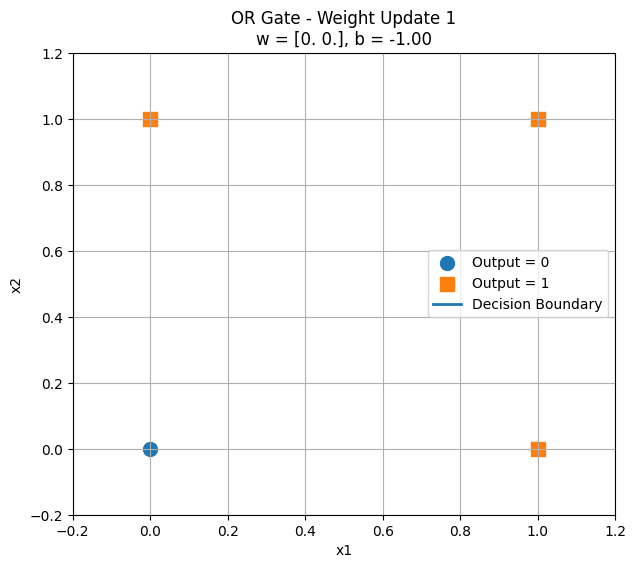

Sample 2: x = [0 1], target = 1, prediction = 0, error = 1
  Old weights = [0. 0.]
  New weights = [0. 1.]
  Old bias    = -1.00
  New bias    = 0.00



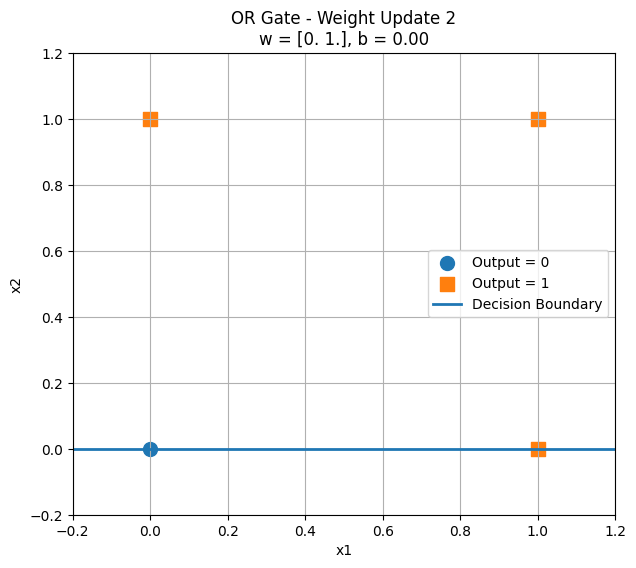

---------- Epoch 2 ----------
Sample 1: x = [0 0], target = 0, prediction = 1, error = -1
  Old weights = [0. 1.]
  New weights = [0. 1.]
  Old bias    = 0.00
  New bias    = -1.00



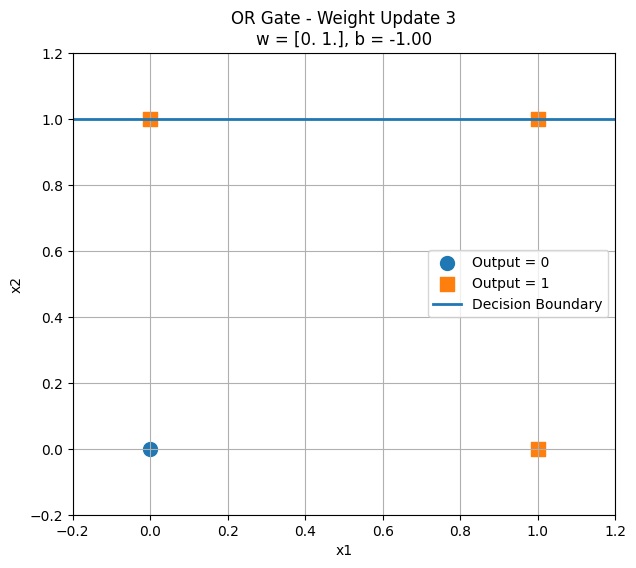

Sample 3: x = [1 0], target = 1, prediction = 0, error = 1
  Old weights = [0. 1.]
  New weights = [1. 1.]
  Old bias    = -1.00
  New bias    = 0.00



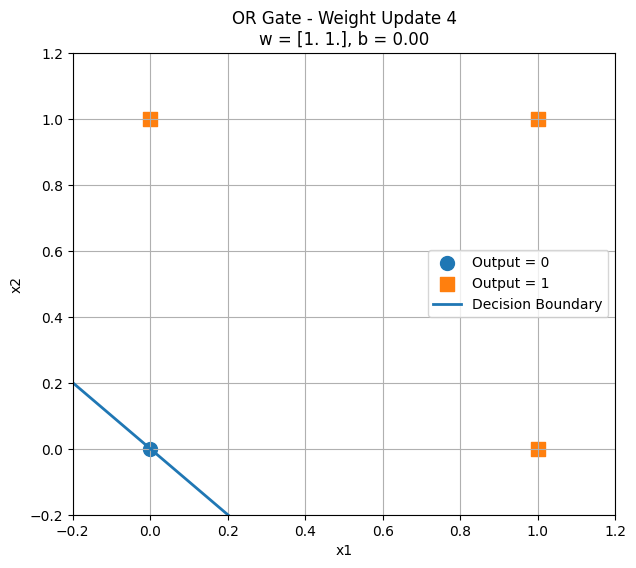

---------- Epoch 3 ----------
Sample 1: x = [0 0], target = 0, prediction = 1, error = -1
  Old weights = [1. 1.]
  New weights = [1. 1.]
  Old bias    = 0.00
  New bias    = -1.00



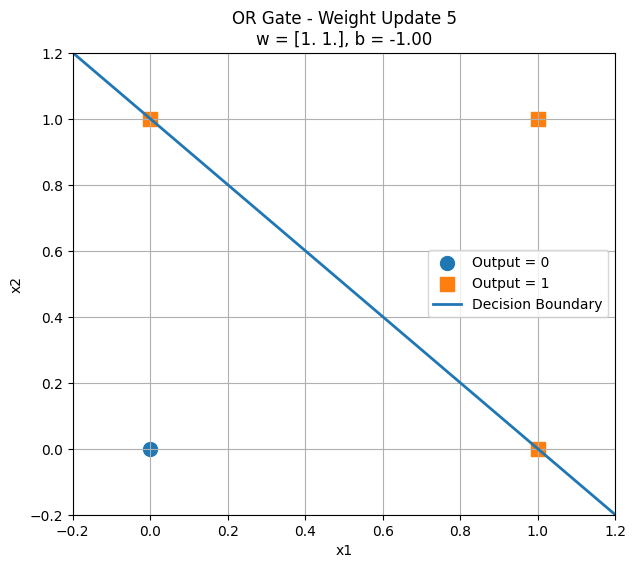

---------- Epoch 4 ----------

OR perceptron converged!
Converged after 4 epoch(s).
Final weights = [1. 1.]
Final bias    = -1.0

AND GATE
Initial weights : [0. 0.]
Initial bias    : 0.0

---------- Epoch 1 ----------
Sample 1: x = [0 0], target = 0, prediction = 1, error = -1
  Old weights = [0. 0.]
  New weights = [0. 0.]
  Old bias    = 0.00
  New bias    = -1.00



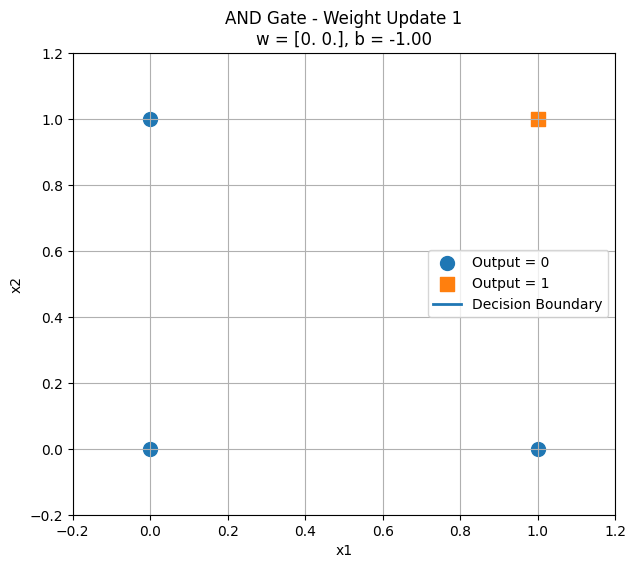

Sample 4: x = [1 1], target = 1, prediction = 0, error = 1
  Old weights = [0. 0.]
  New weights = [1. 1.]
  Old bias    = -1.00
  New bias    = 0.00



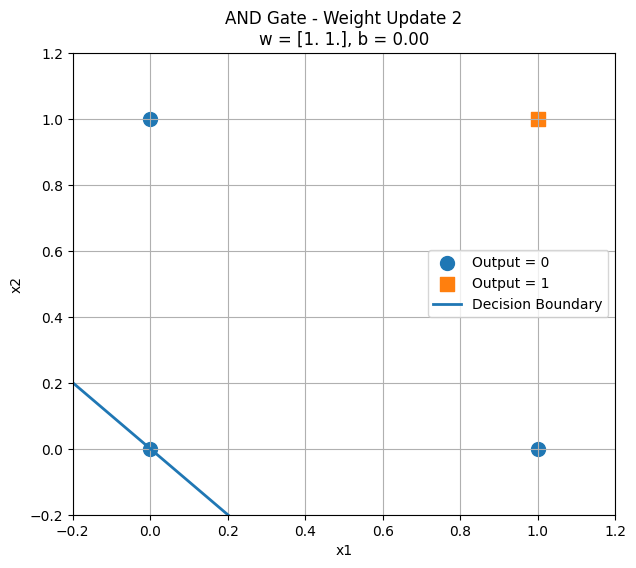

---------- Epoch 2 ----------
Sample 1: x = [0 0], target = 0, prediction = 1, error = -1
  Old weights = [1. 1.]
  New weights = [1. 1.]
  Old bias    = 0.00
  New bias    = -1.00



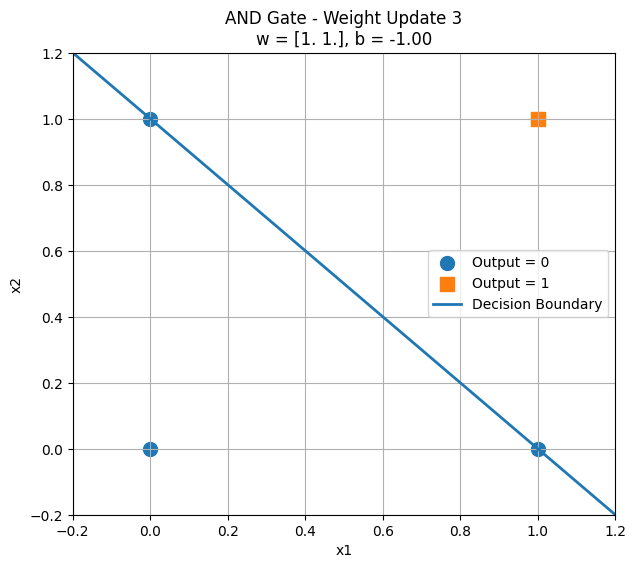

Sample 2: x = [0 1], target = 0, prediction = 1, error = -1
  Old weights = [1. 1.]
  New weights = [1. 0.]
  Old bias    = -1.00
  New bias    = -2.00



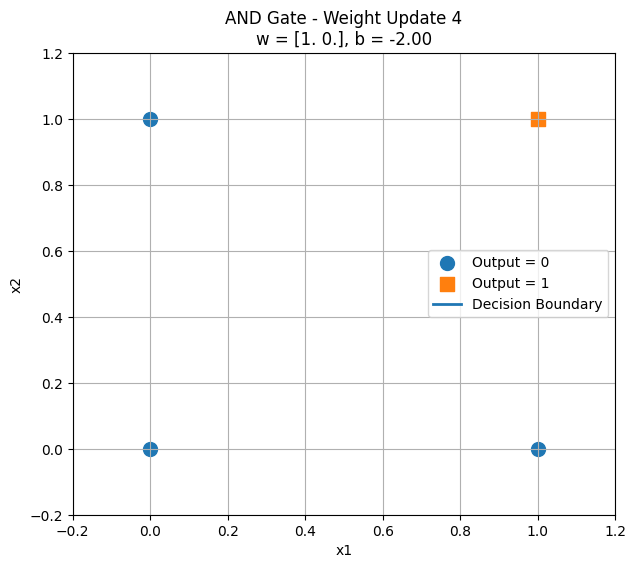

Sample 4: x = [1 1], target = 1, prediction = 0, error = 1
  Old weights = [1. 0.]
  New weights = [2. 1.]
  Old bias    = -2.00
  New bias    = -1.00



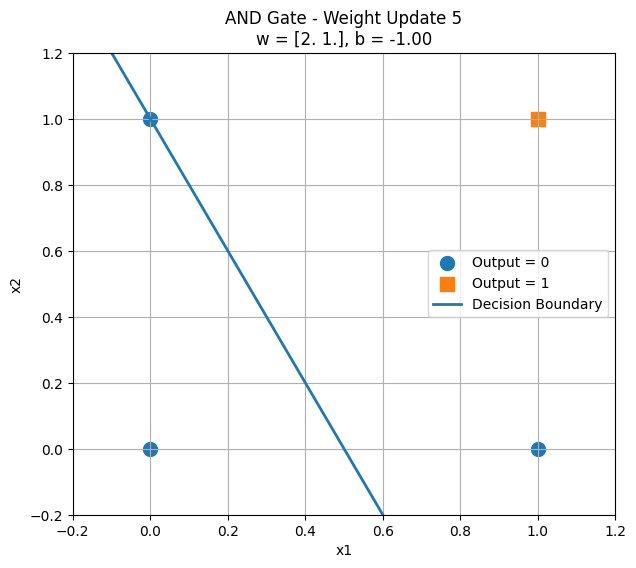

---------- Epoch 3 ----------
Sample 2: x = [0 1], target = 0, prediction = 1, error = -1
  Old weights = [2. 1.]
  New weights = [2. 0.]
  Old bias    = -1.00
  New bias    = -2.00



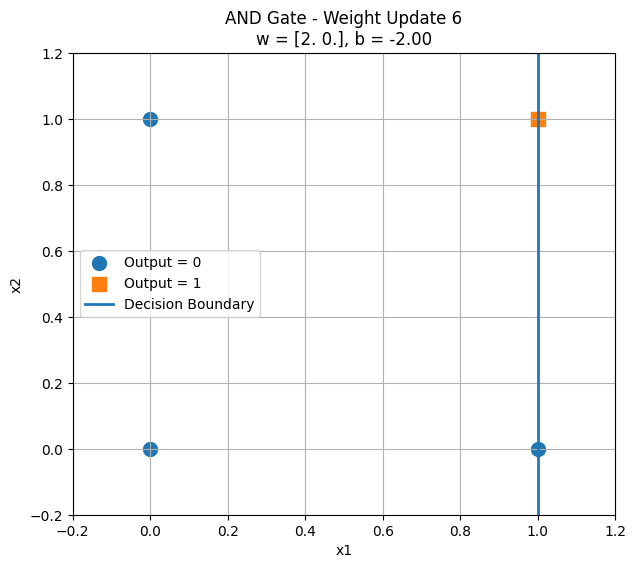

Sample 3: x = [1 0], target = 0, prediction = 1, error = -1
  Old weights = [2. 0.]
  New weights = [1. 0.]
  Old bias    = -2.00
  New bias    = -3.00



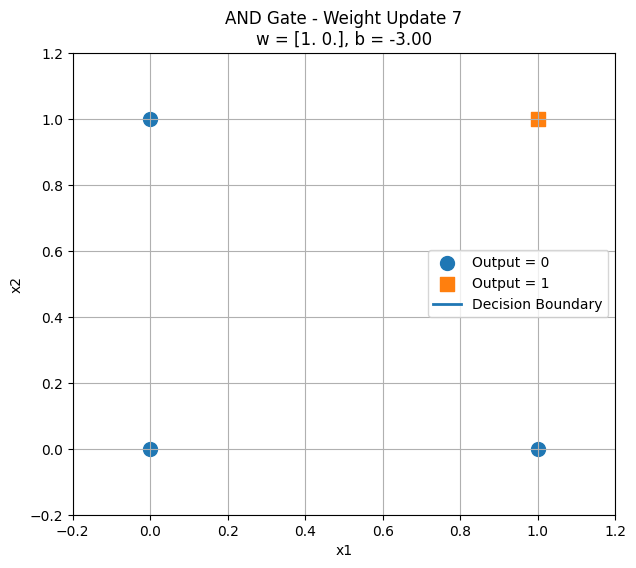

Sample 4: x = [1 1], target = 1, prediction = 0, error = 1
  Old weights = [1. 0.]
  New weights = [2. 1.]
  Old bias    = -3.00
  New bias    = -2.00



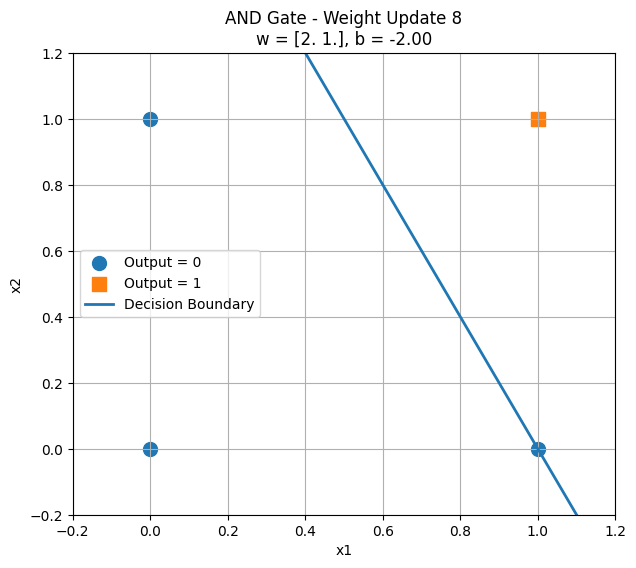

---------- Epoch 4 ----------
Sample 3: x = [1 0], target = 0, prediction = 1, error = -1
  Old weights = [2. 1.]
  New weights = [1. 1.]
  Old bias    = -2.00
  New bias    = -3.00



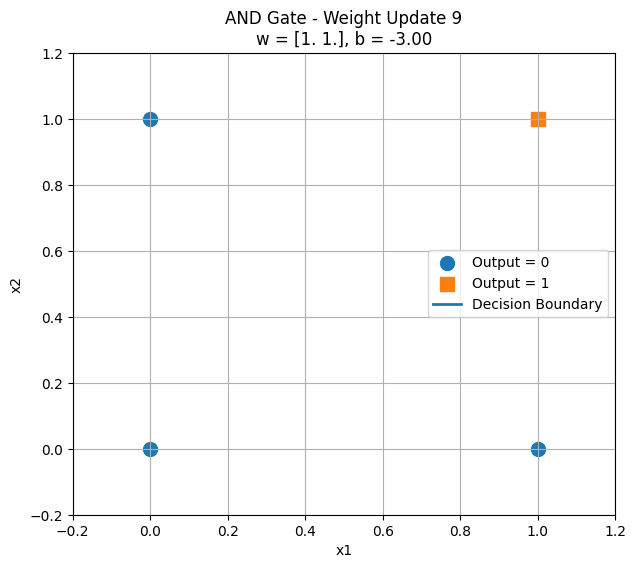

Sample 4: x = [1 1], target = 1, prediction = 0, error = 1
  Old weights = [1. 1.]
  New weights = [2. 2.]
  Old bias    = -3.00
  New bias    = -2.00



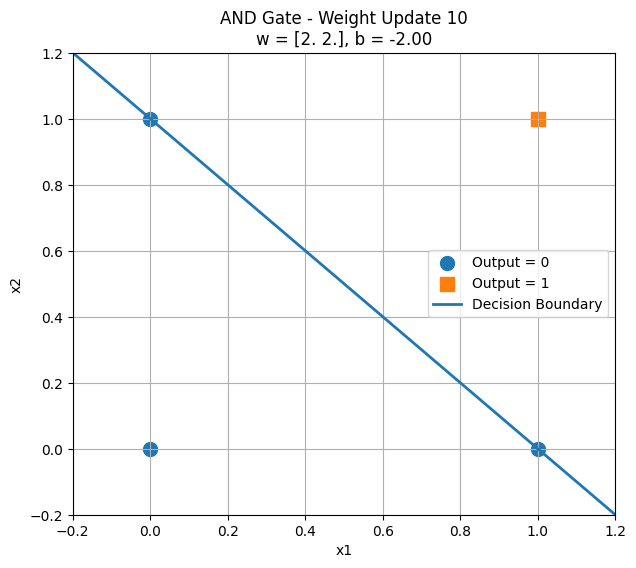

---------- Epoch 5 ----------
Sample 2: x = [0 1], target = 0, prediction = 1, error = -1
  Old weights = [2. 2.]
  New weights = [2. 1.]
  Old bias    = -2.00
  New bias    = -3.00



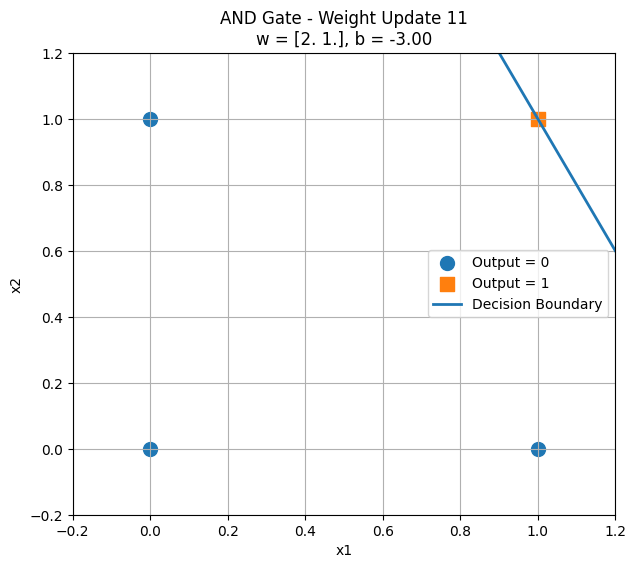

---------- Epoch 6 ----------

AND perceptron converged!
Converged after 6 epoch(s).
Final weights = [2. 1.]
Final bias    = -3.0

NOT GATE
Initial weights : [0. 0.]
Initial bias    : 0.0

---------- Epoch 1 ----------
Sample 2: x = [1 0], target = 0, prediction = 1, error = -1
  Old weights = [0. 0.]
  New weights = [-1.  0.]
  Old bias    = 0.00
  New bias    = -1.00



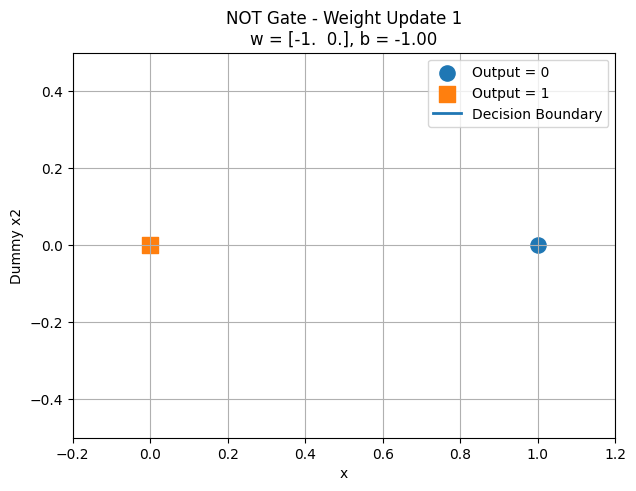

---------- Epoch 2 ----------
Sample 1: x = [0 0], target = 1, prediction = 0, error = 1
  Old weights = [-1.  0.]
  New weights = [-1.  0.]
  Old bias    = -1.00
  New bias    = 0.00



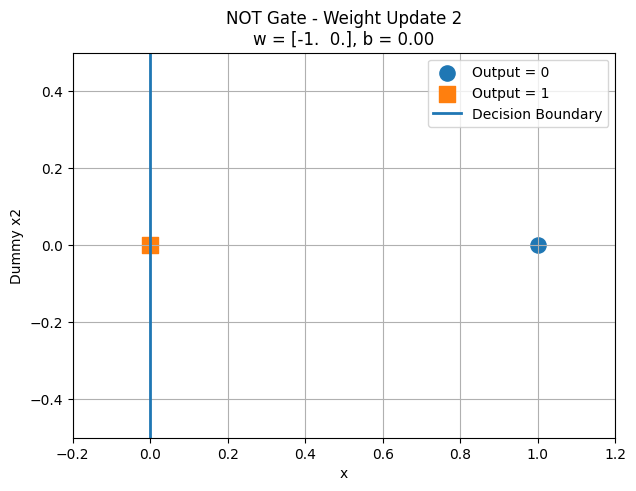

---------- Epoch 3 ----------

NOT perceptron converged!
Converged after 3 epoch(s).
Final weights = [-1.  0.]
Final bias    = 0.0



In [1]:
# ============================================================
# PERCEPTRON LEARNING ALGORITHM
# OR, AND, AND NOT GATES
# ============================================================

import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# Perceptron prediction function
# ------------------------------------------------------------
def predict(x, weights, bias):
    """
    Calculate the perceptron output.

    z = w1*x1 + w2*x2 + bias

    If z >= 0 -> 1
    Otherwise -> 0
    """
    z = np.dot(x, weights) + bias
    return 1 if z >= 0 else 0


# ------------------------------------------------------------
# Plot decision boundary
# ------------------------------------------------------------
def plot_decision_boundary(
    X,
    y,
    weights,
    bias,
    gate_name,
    update_number
):
    """
    Plot the data points and current decision boundary.

    Decision boundary:

        w1*x1 + w2*x2 + b = 0

    Therefore:

        x2 = -(w1*x1 + b) / w2
    """

    plt.figure(figsize=(7, 6))

    # Plot class 0
    class_0 = y == 0
    plt.scatter(
        X[class_0, 0],
        X[class_0, 1],
        marker='o',
        s=100,
        label='Output = 0'
    )

    # Plot class 1
    class_1 = y == 1
    plt.scatter(
        X[class_1, 0],
        X[class_1, 1],
        marker='s',
        s=100,
        label='Output = 1'
    )

    # Generate x-axis values
    x_values = np.linspace(-0.2, 1.2, 200)

    # Avoid division by zero
    if abs(weights[1]) > 1e-10:
        y_values = -(weights[0] * x_values + bias) / weights[1]

        plt.plot(
            x_values,
            y_values,
            linewidth=2,
            label='Decision Boundary'
        )

    else:
        # Vertical decision boundary
        x_boundary = -bias / weights[0]

        plt.axvline(
            x=x_boundary,
            linewidth=2,
            label='Decision Boundary'
        )

    plt.xlim(-0.2, 1.2)
    plt.ylim(-0.2, 1.2)

    plt.xlabel("x1")
    plt.ylabel("x2")

    plt.title(
        f"{gate_name} Gate - Weight Update {update_number}\n"
        f"w = {weights}, b = {bias:.2f}"
    )

    plt.grid(True)
    plt.legend()

    # --------------------------------------------------------
    # Save as EPS with 600 DPI
    # --------------------------------------------------------
    filename = f"{gate_name.lower()}_update_{update_number}.eps"

    plt.savefig(
        filename,
        format="eps",
        dpi=600,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()


# ------------------------------------------------------------
# Perceptron training function
# ------------------------------------------------------------
def train_perceptron(
    X,
    y,
    gate_name,
    learning_rate=1,
    max_epochs=20
):
    """
    Train a perceptron using the perceptron learning rule.

    Weight update:

        w_new = w_old + learning_rate * error * x

    Bias update:

        b_new = b_old + learning_rate * error

    where:

        error = target - prediction
    """

    # Initialize weights and bias
    weights = np.zeros(X.shape[1])
    bias = 0.0

    update_number = 0

    print("=" * 70)
    print(f"{gate_name} GATE")
    print("=" * 70)

    print(f"Initial weights : {weights}")
    print(f"Initial bias    : {bias}")
    print()

    for epoch in range(1, max_epochs + 1):

        errors = 0

        print(f"---------- Epoch {epoch} ----------")

        for i in range(len(X)):

            # Prediction
            prediction = predict(
                X[i],
                weights,
                bias
            )

            # Calculate error
            error = y[i] - prediction

            # Update only if prediction is incorrect
            if error != 0:

                old_weights = weights.copy()
                old_bias = bias

                # Weight update
                weights = (
                    weights
                    + learning_rate * error * X[i]
                )

                # Bias update
                bias = (
                    bias
                    + learning_rate * error
                )

                update_number += 1
                errors += 1

                print(
                    f"Sample {i + 1}: "
                    f"x = {X[i]}, "
                    f"target = {y[i]}, "
                    f"prediction = {prediction}, "
                    f"error = {error}"
                )

                print(
                    f"  Old weights = {old_weights}"
                )

                print(
                    f"  New weights = {weights}"
                )

                print(
                    f"  Old bias    = {old_bias:.2f}"
                )

                print(
                    f"  New bias    = {bias:.2f}"
                )

                print()

                # Plot after every weight update
                plot_decision_boundary(
                    X,
                    y,
                    weights,
                    bias,
                    gate_name,
                    update_number
                )

        # If no errors occurred, perceptron has converged
        if errors == 0:

            print()
            print(f"{gate_name} perceptron converged!")
            print(f"Converged after {epoch} epoch(s).")
            print(f"Final weights = {weights}")
            print(f"Final bias    = {bias}")
            print()

            return weights, bias

    print()
    print(
        f"{gate_name} perceptron did not converge "
        f"within {max_epochs} epochs."
    )
    print()

    return weights, bias


# ============================================================
# DATASETS
# ============================================================

# Input combinations
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])


# ------------------------------------------------------------
# OR GATE
# ------------------------------------------------------------
y_or = np.array([
    0,
    1,
    1,
    1
])


# ------------------------------------------------------------
# AND GATE
# ------------------------------------------------------------
y_and = np.array([
    0,
    0,
    0,
    1
])


# ============================================================
# TRAIN OR PERCEPTRON
# ============================================================

or_weights, or_bias = train_perceptron(
    X,
    y_or,
    gate_name="OR",
    learning_rate=1,
    max_epochs=20
)


# ============================================================
# TRAIN AND PERCEPTRON
# ============================================================

and_weights, and_bias = train_perceptron(
    X,
    y_and,
    gate_name="AND",
    learning_rate=1,
    max_epochs=20
)


# ============================================================
# NOT GATE
# ============================================================
#
# NOT has only one input.
#
# Input:
#     0 -> 1
#     1 -> 0
#
# To allow the same decision-boundary plotting function,
# we represent the second input as 0.
# Therefore:
#
#     [0,0] -> 1
#     [1,0] -> 0
#
# ------------------------------------------------------------

X_not = np.array([
    [0, 0],
    [1, 0]
])

y_not = np.array([
    1,
    0
])


# ------------------------------------------------------------
# Special plotting function for NOT gate
# ------------------------------------------------------------
def plot_not_boundary(
    X,
    y,
    weights,
    bias,
    update_number
):

    plt.figure(figsize=(7, 5))

    class_0 = y == 0
    class_1 = y == 1

    plt.scatter(
        X[class_0, 0],
        X[class_0, 1],
        marker='o',
        s=120,
        label='Output = 0'
    )

    plt.scatter(
        X[class_1, 0],
        X[class_1, 1],
        marker='s',
        s=120,
        label='Output = 1'
    )

    # For NOT gate:
    #
    # w*x + b = 0
    #
    # x = -b/w

    if abs(weights[0]) > 1e-10:

        x_boundary = -bias / weights[0]

        plt.axvline(
            x=x_boundary,
            linewidth=2,
            label='Decision Boundary'
        )

    plt.xlim(-0.2, 1.2)
    plt.ylim(-0.5, 0.5)

    plt.xlabel("x")
    plt.ylabel("Dummy x2")

    plt.title(
        f"NOT Gate - Weight Update {update_number}\n"
        f"w = {weights}, b = {bias:.2f}"
    )

    plt.grid(True)
    plt.legend()

    filename = f"not_update_{update_number}.eps"

    plt.savefig(
        filename,
        format="eps",
        dpi=600,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()


# ------------------------------------------------------------
# Train NOT perceptron
# ------------------------------------------------------------
def train_not_perceptron(
    X,
    y,
    learning_rate=1,
    max_epochs=20
):

    weights = np.zeros(X.shape[1])
    bias = 0.0

    update_number = 0

    print("=" * 70)
    print("NOT GATE")
    print("=" * 70)

    print(f"Initial weights : {weights}")
    print(f"Initial bias    : {bias}")
    print()

    for epoch in range(1, max_epochs + 1):

        errors = 0

        print(f"---------- Epoch {epoch} ----------")

        for i in range(len(X)):

            prediction = predict(
                X[i],
                weights,
                bias
            )

            error = y[i] - prediction

            if error != 0:

                old_weights = weights.copy()
                old_bias = bias

                weights = (
                    weights
                    + learning_rate * error * X[i]
                )

                bias = (
                    bias
                    + learning_rate * error
                )

                update_number += 1
                errors += 1

                print(
                    f"Sample {i + 1}: "
                    f"x = {X[i]}, "
                    f"target = {y[i]}, "
                    f"prediction = {prediction}, "
                    f"error = {error}"
                )

                print(
                    f"  Old weights = {old_weights}"
                )

                print(
                    f"  New weights = {weights}"
                )

                print(
                    f"  Old bias    = {old_bias:.2f}"
                )

                print(
                    f"  New bias    = {bias:.2f}"
                )

                print()

                plot_not_boundary(
                    X,
                    y,
                    weights,
                    bias,
                    update_number
                )

        if errors == 0:

            print()
            print("NOT perceptron converged!")
            print(f"Converged after {epoch} epoch(s).")
            print(f"Final weights = {weights}")
            print(f"Final bias    = {bias}")
            print()

            return weights, bias

    return weights, bias


not_weights, not_bias = train_not_perceptron(
    X_not,
    y_not,
    learning_rate=1,
    max_epochs=20
)

XOR PERCEPTRON
Initial weights = [0. 0.]
Initial bias    = 0.0

Weight Update 1
----------------------------------------
Input       : [0 0]
Target      : 0
Prediction  : 1
Error       : -1
Old weights : [0. 0.]
New weights : [0. 0.]
Old bias    : 0.00
New bias    : -1.00

Weight Update 2
----------------------------------------
Input       : [0 1]
Target      : 1
Prediction  : 0
Error       : 1
Old weights : [0. 0.]
New weights : [0. 1.]
Old bias    : -1.00
New bias    : 0.00

Weight Update 3
----------------------------------------
Input       : [1 1]
Target      : 0
Prediction  : 1
Error       : -1
Old weights : [0. 1.]
New weights : [-1.  0.]
Old bias    : 0.00
New bias    : -1.00

Weight Update 4
----------------------------------------
Input       : [0 1]
Target      : 1
Prediction  : 0
Error       : 1
Old weights : [-1.  0.]
New weights : [-1.  1.]
Old bias    : -1.00
New bias    : 0.00

Weight Update 5
----------------------------------------
Input       : [1 0]
Target      : 1

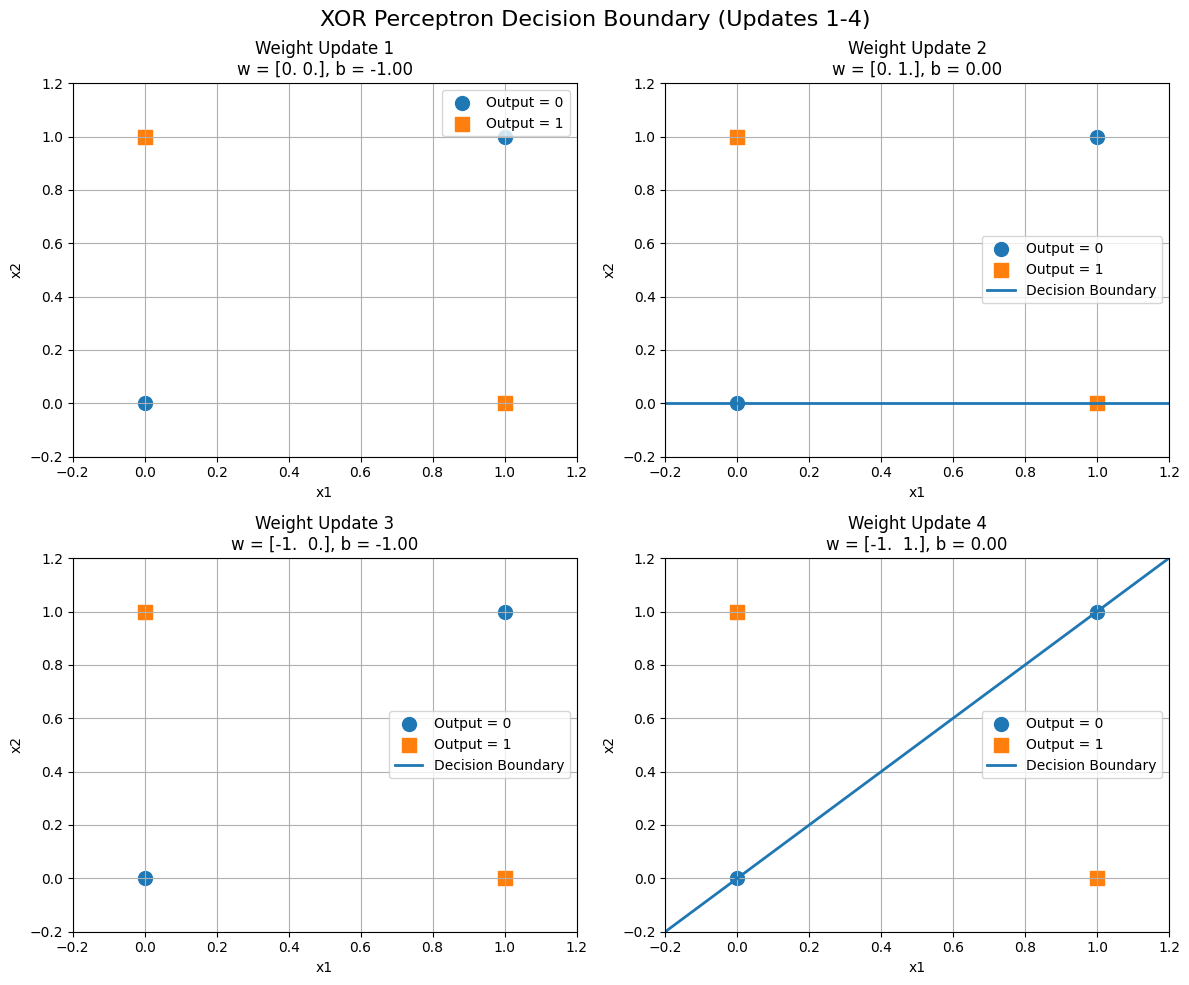

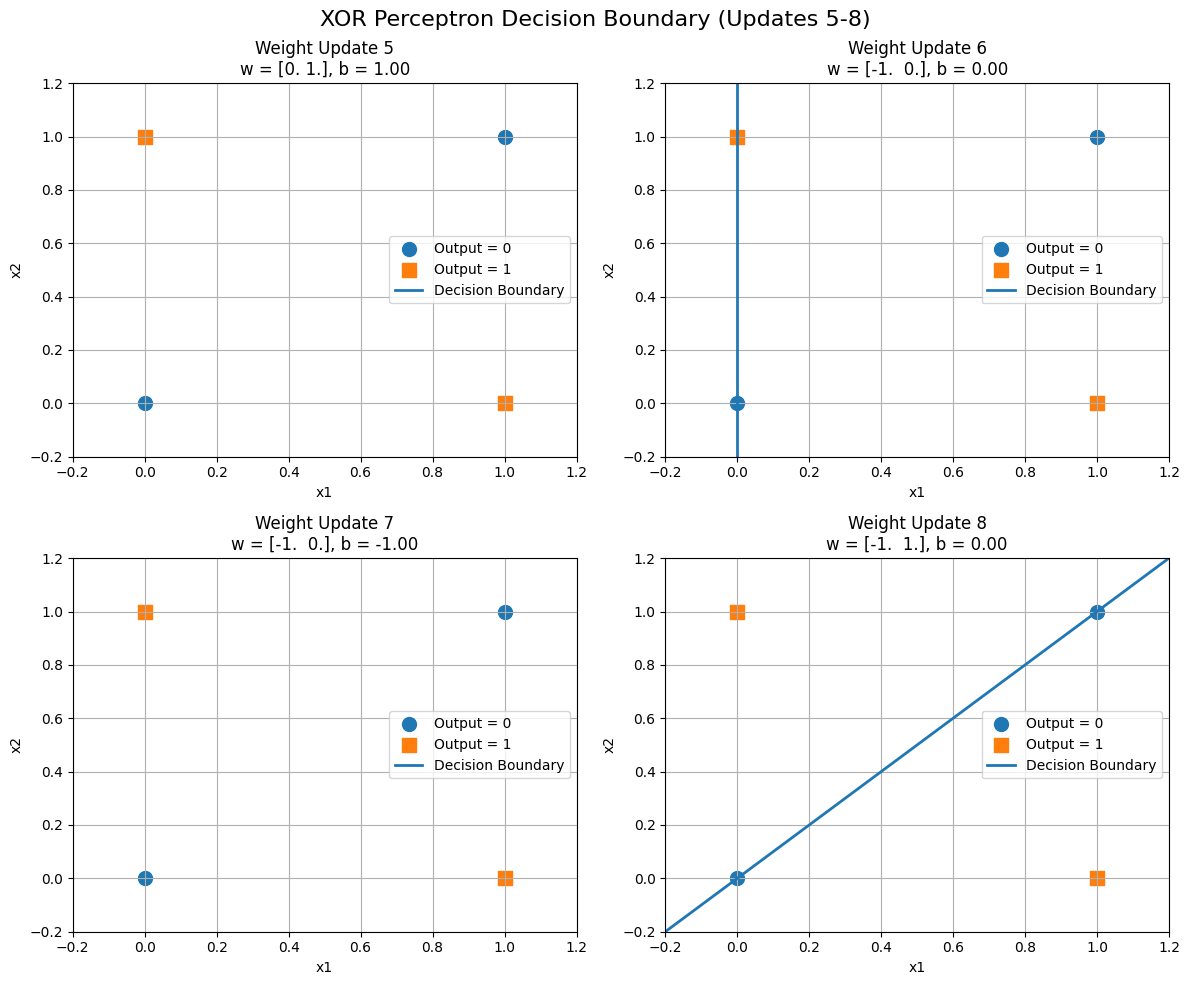

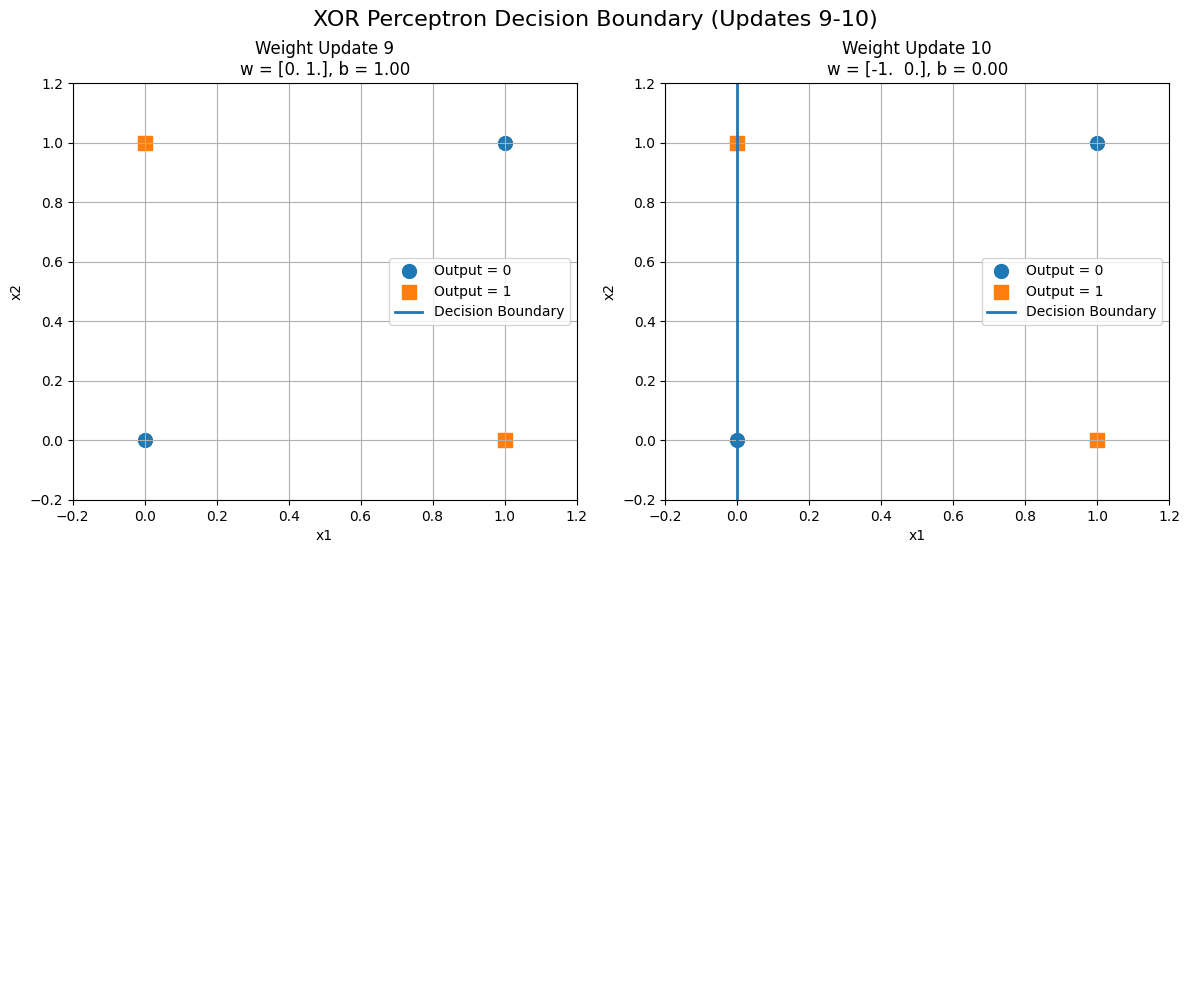

FINAL RESULT
Total updates performed: 10
Final weights: [-1.  0.]
Final bias: 0.0

Final predictions:
Input = [0 0] | Target = 0 | Prediction = 1
Input = [0 1] | Target = 1 | Prediction = 1
Input = [1 0] | Target = 1 | Prediction = 0
Input = [1 1] | Target = 0 | Prediction = 0

Observation:
The perceptron fails to converge because XOR is not linearly separable. The decision boundary keeps changing as the algorithm attempts to correct misclassified samples.


In [4]:
# ============================================================
# XOR PERCEPTRON - 4 UPDATES PER FIGURE
# ============================================================

import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# XOR DATASET
# ============================================================

X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
], dtype=float)

y = np.array([0, 1, 1, 0])


# ============================================================
# PARAMETERS
# ============================================================

learning_rate = 1
max_updates = 10

weights = np.zeros(2)
bias = 0.0

update_count = 0


# ============================================================
# STORE UPDATE STATES
# ============================================================

update_states = []


# ============================================================
# TRAINING
# ============================================================

print("=" * 65)
print("XOR PERCEPTRON")
print("=" * 65)

print(f"Initial weights = {weights}")
print(f"Initial bias    = {bias}")
print()


while update_count < max_updates:

    errors = 0

    for i in range(len(X)):

        # Calculate prediction
        z = np.dot(X[i], weights) + bias

        prediction = 1 if z >= 0 else 0

        # Calculate error
        error = y[i] - prediction

        # Update weights
        if error != 0:

            old_weights = weights.copy()
            old_bias = bias

            weights = (
                weights
                + learning_rate * error * X[i]
            )

            bias = (
                bias
                + learning_rate * error
            )

            update_count += 1
            errors += 1

            # ------------------------------------------------
            # Print update information
            # ------------------------------------------------

            print(f"Weight Update {update_count}")
            print("-" * 40)

            print(f"Input       : {X[i].astype(int)}")
            print(f"Target      : {y[i]}")
            print(f"Prediction  : {prediction}")
            print(f"Error       : {error}")

            print(f"Old weights : {old_weights}")
            print(f"New weights : {weights}")

            print(f"Old bias    : {old_bias:.2f}")
            print(f"New bias    : {bias:.2f}")

            print()

            # ------------------------------------------------
            # Save current state
            # ------------------------------------------------

            update_states.append({
                "update": update_count,
                "weights": weights.copy(),
                "bias": bias
            })

            if update_count >= max_updates:
                break

    if errors == 0:
        print("Perceptron converged!")
        break


# ============================================================
# PLOT 4 UPDATES PER FIGURE
# ============================================================

for start in range(0, len(update_states), 4):

    group = update_states[start:start + 4]

    # Create 2 x 2 subplot
    fig, axes = plt.subplots(
        2,
        2,
        figsize=(12, 10)
    )

    # Flatten axes for easier indexing
    axes = axes.flatten()

    for j, state in enumerate(group):

        ax = axes[j]

        current_weights = state["weights"]
        current_bias = state["bias"]
        current_update = state["update"]

        # ----------------------------------------------------
        # Plot class 0
        # ----------------------------------------------------

        class_0 = y == 0

        ax.scatter(
            X[class_0, 0],
            X[class_0, 1],
            marker='o',
            s=100,
            label='Output = 0'
        )

        # ----------------------------------------------------
        # Plot class 1
        # ----------------------------------------------------

        class_1 = y == 1

        ax.scatter(
            X[class_1, 0],
            X[class_1, 1],
            marker='s',
            s=100,
            label='Output = 1'
        )

        # ----------------------------------------------------
        # Plot decision boundary
        # ----------------------------------------------------

        x_values = np.linspace(-0.2, 1.2, 200)

        if abs(current_weights[1]) > 1e-10:

            y_values = (
                -(
                    current_weights[0] * x_values
                    + current_bias
                )
                / current_weights[1]
            )

            ax.plot(
                x_values,
                y_values,
                linewidth=2,
                label='Decision Boundary'
            )

        elif abs(current_weights[0]) > 1e-10:

            x_boundary = (
                -current_bias
                / current_weights[0]
            )

            ax.axvline(
                x=x_boundary,
                linewidth=2,
                label='Decision Boundary'
            )

        # ----------------------------------------------------
        # Formatting
        # ----------------------------------------------------

        ax.set_xlim(-0.2, 1.2)
        ax.set_ylim(-0.2, 1.2)

        ax.set_xlabel("x1")
        ax.set_ylabel("x2")

        ax.set_title(
            f"Weight Update {current_update}\n"
            f"w = {current_weights}, "
            f"b = {current_bias:.2f}"
        )

        ax.grid(True)
        ax.legend()

    # --------------------------------------------------------
    # Hide unused subplots
    # --------------------------------------------------------

    for j in range(len(group), 4):
        axes[j].axis("off")

    # --------------------------------------------------------
    # Overall title
    # --------------------------------------------------------

    first_update = group[0]["update"]
    last_update = group[-1]["update"]

    fig.suptitle(
        f"XOR Perceptron Decision Boundary "
        f"(Updates {first_update}-{last_update})",
        fontsize=16
    )

    plt.tight_layout()

    # --------------------------------------------------------
    # Save as EPS at 600 DPI
    # --------------------------------------------------------

    filename = (
        f"xor_updates_{first_update}_"
        f"to_{last_update}.eps"
    )

    plt.savefig(
        filename,
        format="eps",
        dpi=600,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()


# ============================================================
# FINAL RESULT
# ============================================================

print("=" * 65)
print("FINAL RESULT")
print("=" * 65)

print(f"Total updates performed: {update_count}")
print(f"Final weights: {weights}")
print(f"Final bias: {bias}")

print()
print("Final predictions:")

for i in range(len(X)):

    z = np.dot(X[i], weights) + bias

    prediction = 1 if z >= 0 else 0

    print(
        f"Input = {X[i].astype(int)} | "
        f"Target = {y[i]} | "
        f"Prediction = {prediction}"
    )

print()
print("Observation:")
print(
    "The perceptron fails to converge because XOR is "
    "not linearly separable. The decision boundary keeps "
    "changing as the algorithm attempts to correct "
    "misclassified samples."
)

Epoch     1 | Loss = 0.71410837 | Accuracy = 50.00%
Epoch   100 | Loss = 0.69297733 | Accuracy = 50.00%
Epoch   200 | Loss = 0.67857744 | Accuracy = 75.00%
Epoch   300 | Loss = 0.44488728 | Accuracy = 75.00%
Epoch   400 | Loss = 0.07253472 | Accuracy = 100.00%
Epoch   500 | Loss = 0.03094989 | Accuracy = 100.00%
Epoch   600 | Loss = 0.01923397 | Accuracy = 100.00%
Epoch   700 | Loss = 0.01385668 | Accuracy = 100.00%
Epoch   800 | Loss = 0.01079548 | Accuracy = 100.00%
MLP CONVERGED
Convergence epoch : 836
Final loss        : 0.00999511
Final accuracy    : 100.00%

MLP converged at epoch 836.

FINAL XOR PREDICTIONS
Input = [0 0] | Target = 0 | Output = 0.012011 | Prediction = 0
Input = [0 1] | Target = 1 | Output = 0.990988 | Prediction = 1
Input = [1 0] | Target = 1 | Output = 0.990964 | Prediction = 1
Input = [1 1] | Target = 0 | Output = 0.009719 | Prediction = 0

FINAL WEIGHTS

Input -> Hidden weights:
[[6.79850892 4.92180862]
 [6.82395286 4.92643222]]

Hidden biases:
[[-3.04609521 

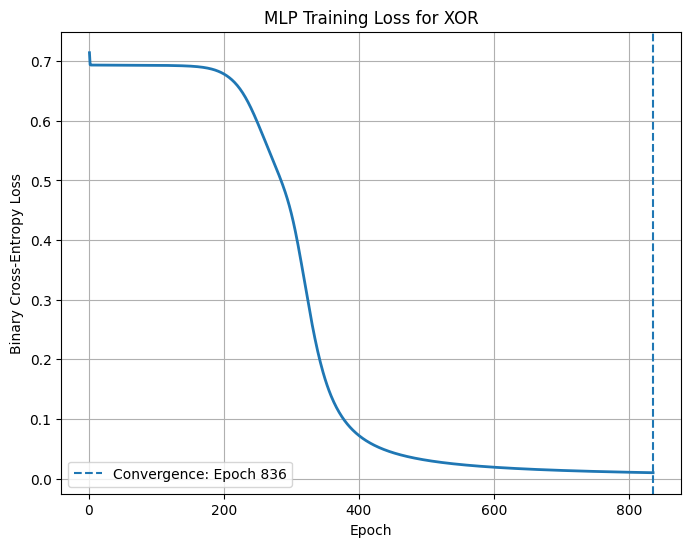

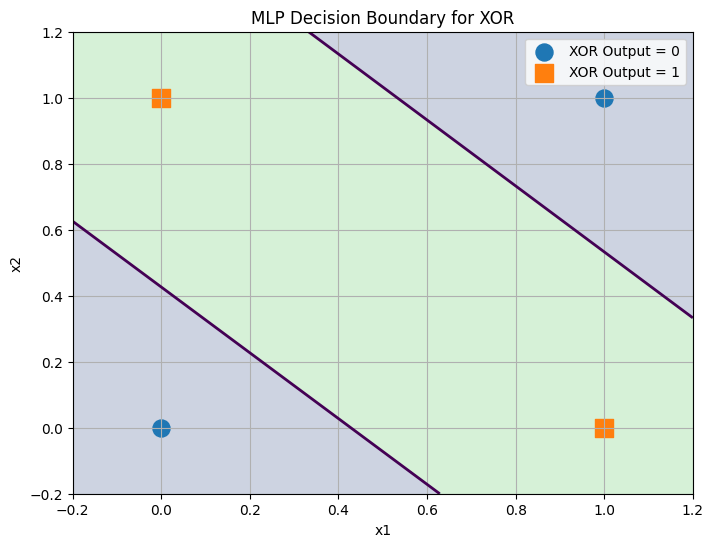

In [6]:
# ============================================================
# MLP FOR XOR
# Architecture: 2 -> 2 -> 1
# One hidden layer
# ============================================================

import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# XOR DATASET
# ============================================================

X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
], dtype=float)

y = np.array([
    [0],
    [1],
    [1],
    [0]
], dtype=float)


# ============================================================
# SIGMOID FUNCTION
# ============================================================

def sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z))


# ============================================================
# INITIALIZE WEIGHTS
# ============================================================

np.random.seed(42)

# Input layer -> Hidden layer
W1 = np.random.randn(2, 2) * 0.5
b1 = np.random.randn(1, 2) * 0.5

# Hidden layer -> Output layer
W2 = np.random.randn(2, 1) * 0.5
b2 = np.random.randn(1, 1) * 0.5


# ============================================================
# HYPERPARAMETERS
# ============================================================

learning_rate = 2.0
max_epochs = 10000

# Convergence criterion
loss_threshold = 0.01


# ============================================================
# TRAINING
# ============================================================

loss_history = []
convergence_epoch = None

for epoch in range(1, max_epochs + 1):

    # --------------------------------------------------------
    # FORWARD PROPAGATION
    # --------------------------------------------------------

    # Input -> Hidden
    z1 = np.dot(X, W1) + b1
    a1 = sigmoid(z1)

    # Hidden -> Output
    z2 = np.dot(a1, W2) + b2
    a2 = sigmoid(z2)


    # --------------------------------------------------------
    # BINARY CROSS-ENTROPY LOSS
    # --------------------------------------------------------

    loss = -np.mean(
        y * np.log(a2 + 1e-12)
        + (1 - y) * np.log(1 - a2 + 1e-12)
    )

    loss_history.append(loss)


    # --------------------------------------------------------
    # PREDICTIONS
    # --------------------------------------------------------

    predictions = (a2 >= 0.5).astype(int)

    accuracy = np.mean(predictions == y)


    # --------------------------------------------------------
    # CHECK CONVERGENCE
    # --------------------------------------------------------

    if loss < loss_threshold and accuracy == 1.0:

        convergence_epoch = epoch

        print("=" * 60)
        print("MLP CONVERGED")
        print("=" * 60)
        print(f"Convergence epoch : {convergence_epoch}")
        print(f"Final loss        : {loss:.8f}")
        print(f"Final accuracy    : {accuracy * 100:.2f}%")
        print()

        break


    # --------------------------------------------------------
    # BACKPROPAGATION
    # --------------------------------------------------------

    # Output layer gradient
    dz2 = a2 - y

    dW2 = np.dot(a1.T, dz2) / len(X)
    db2 = np.mean(dz2, axis=0, keepdims=True)


    # Hidden layer gradient
    dz1 = (
        np.dot(dz2, W2.T)
        * a1
        * (1 - a1)
    )

    dW1 = np.dot(X.T, dz1) / len(X)
    db1 = np.mean(dz1, axis=0, keepdims=True)


    # --------------------------------------------------------
    # UPDATE WEIGHTS
    # --------------------------------------------------------

    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2

    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1


    # --------------------------------------------------------
    # DISPLAY TRAINING PROGRESS
    # --------------------------------------------------------

    if epoch == 1 or epoch % 100 == 0:

        print(
            f"Epoch {epoch:5d} | "
            f"Loss = {loss:.8f} | "
            f"Accuracy = {accuracy * 100:.2f}%"
        )


# ============================================================
# CONVERGENCE CHECK
# ============================================================

if convergence_epoch is None:

    print("=" * 60)
    print("MLP DID NOT CONVERGE")
    print("=" * 60)

    print(
        f"Maximum epochs reached: {max_epochs}"
    )

else:

    print(
        f"MLP converged at epoch {convergence_epoch}."
    )


# ============================================================
# FINAL PREDICTIONS
# ============================================================

print()
print("=" * 60)
print("FINAL XOR PREDICTIONS")
print("=" * 60)

# Forward propagation

z1 = np.dot(X, W1) + b1
a1 = sigmoid(z1)

z2 = np.dot(a1, W2) + b2
a2 = sigmoid(z2)

predictions = (a2 >= 0.5).astype(int)

for i in range(len(X)):

    print(
        f"Input = {X[i].astype(int)} | "
        f"Target = {int(y[i, 0])} | "
        f"Output = {a2[i, 0]:.6f} | "
        f"Prediction = {predictions[i, 0]}"
    )


# ============================================================
# FINAL WEIGHTS
# ============================================================

print()
print("=" * 60)
print("FINAL WEIGHTS")
print("=" * 60)

print("\nInput -> Hidden weights:")
print(W1)

print("\nHidden biases:")
print(b1)

print("\nHidden -> Output weights:")
print(W2)

print("\nOutput bias:")
print(b2)


# ============================================================
# PLOT 1: TRAINING LOSS
# ============================================================

plt.figure(figsize=(8, 6))

plt.plot(
    range(1, len(loss_history) + 1),
    loss_history,
    linewidth=2
)

plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("MLP Training Loss for XOR")
plt.grid(True)

if convergence_epoch is not None:

    plt.axvline(
        convergence_epoch,
        linestyle="--",
        linewidth=1.5,
        label=f"Convergence: Epoch {convergence_epoch}"
    )

    plt.legend()

plt.savefig(
    "mlp_xor_training_loss.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()
plt.close()


# ============================================================
# PLOT 2: DECISION BOUNDARY
# ============================================================

# Create grid
x_min, x_max = -0.2, 1.2
y_min, y_max = -0.2, 1.2

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 400),
    np.linspace(y_min, y_max, 400)
)

grid = np.c_[
    xx.ravel(),
    yy.ravel()
]


# ------------------------------------------------------------
# Forward propagation through trained MLP
# ------------------------------------------------------------

grid_z1 = np.dot(grid, W1) + b1
grid_a1 = sigmoid(grid_z1)

grid_z2 = np.dot(grid_a1, W2) + b2
grid_a2 = sigmoid(grid_z2)

grid_output = grid_a2.reshape(xx.shape)


# ------------------------------------------------------------
# Plot decision regions
# ------------------------------------------------------------

plt.figure(figsize=(8, 6))

plt.contourf(
    xx,
    yy,
    grid_output >= 0.5,
    levels=[-0.5, 0.5, 1.5],
    alpha=0.25
)


# ------------------------------------------------------------
# Plot actual 0.5 decision boundary
# ------------------------------------------------------------

plt.contour(
    xx,
    yy,
    grid_output,
    levels=[0.5],
    linewidths=2
)


# ------------------------------------------------------------
# Plot XOR points
# ------------------------------------------------------------

class_0 = y.ravel() == 0
class_1 = y.ravel() == 1

plt.scatter(
    X[class_0, 0],
    X[class_0, 1],
    marker="o",
    s=150,
    label="XOR Output = 0"
)

plt.scatter(
    X[class_1, 0],
    X[class_1, 1],
    marker="s",
    s=150,
    label="XOR Output = 1"
)


plt.xlabel("x1")
plt.ylabel("x2")

plt.title("MLP Decision Boundary for XOR")

plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)

plt.grid(True)
plt.legend()

plt.savefig(
    "mlp_xor_decision_boundary.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()
plt.close()